# RNA implementation to SCICoNE

In [1]:
#import libraries

import scicone
import numpy as np
import pickle
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import io
import scanpy as sc
import anndata
import pyranges
import gseapy as gp

# Set up SCICoNE
install_path = '/cluster/work/bewi/members/andress/pylabs/SCICoNE/build/'
install_path_local = "/home/andress/pylabs/SCICoNE_lab/build/"
temporary_outpath = './'

seed = 42 # for reproducibility

np.random.seed(seed)

# Create SCICoNE object
sci = scicone.SCICoNE(install_path_local, temporary_outpath, verbose=False)

Using binaries at /home/andress/pylabs/SCICoNE_lab/build/


In [2]:


# Define paths
scdna_path_ssh = '/cluster/work/bewi/members/andress/SCICoNE_lab/rna_imp/clonealign-processed-data/SA501/cnv/'
scrna_path_ssh = '/cluster/work/bewi/members/andress/SCICoNE_lab/rna_imp/clonealign-processed-data/SA501/10X/20171026_SA501X2XB00096/outs/filtered_gene_bc_matrices/hg19/'

scdna_path_local = '/home/andress/pylabs/SCICoNE_lab/rna_imp/SA501/cnv'
scrna_path_local = '/home/andress/pylabs/SCICoNE_lab/rna_imp/SA501/10X/20171026_SA501X2XB00096/outs/filtered_gene_bc_matrices/hg19'

# Try SSH paths first
try:
    if os.path.exists(scdna_path_ssh) and os.path.exists(scrna_path_ssh):
        scdna_path = scdna_path_ssh
        scrna_path = scrna_path_ssh
    else:
        raise FileNotFoundError("SSH paths are not accessible.")
except FileNotFoundError:
    # Use local paths
    if os.path.exists(scdna_path_local) and os.path.exists(scrna_path_local):
        scdna_path = scdna_path_local
        scrna_path = scrna_path_local
    else:
        raise FileNotFoundError("Neither SSH nor local paths are accessible.")

In [3]:
annot = sc.queries.biomart_annotations(
        "hsapiens",
        ["ensembl_gene_id", "start_position", "end_position", "chromosome_name"],
    ).set_index("ensembl_gene_id")

annot = annot.reset_index()
annot = annot.rename(columns={'start_position':'Start', 'end_position': 'End', 'chromosome_name': 'Chromosome'})

gr_annotations = pyranges.from_dict(annot.to_dict())

gr_annotations.head()

,ensembl_gene_id,Start,End,Chromosome
0,ENSG00000142611,3069168,3438621,1
1,ENSG00000284616,5301928,5307394,1
2,ENSG00000157911,2403964,2413797,1
3,ENSG00000260972,5492978,5494674,1
4,ENSG00000224340,10054445,10054781,1
5,ENSG00000229280,4175528,4175899,1
6,ENSG00000142655,10472288,10630758,1
7,ENSG00000232596,4571481,4594016,1


In [4]:
# Convert PyRanges object to a pandas DataFrame
gr_annotations_df = gr_annotations.df

# Save the DataFrame as a CSV file
gr_annotations_df.to_csv(os.path.join(temporary_outpath, 'gr_annotations.csv'), index=False)

# Read scRNA data

In [5]:
#read data

mat = io.mmread(f'{scrna_path}/matrix.mtx').toarray()
barcodes = pd.read_csv(f'{scrna_path}/barcodes.tsv', sep='\t', header=None)
genes = pd.read_csv(f'{scrna_path}/genes.tsv', sep='\t', header=None)


In [6]:
adata = anndata.AnnData(pd.DataFrame(mat.T, index=barcodes[0].values, columns=genes[0].values))
adata.var_names_make_unique()
adata.var['ensembl_gene_id'] = genes[0].values
adata.var['gene_id'] = genes[1].values
print(adata.obs_names[:5])  # First 5 observation names (e.g., barcodes)
print(adata.var_names[:5])  # First 5 variable names (e.g., gene names)
print(adata.shape)  # Should return (number of cells, number of genes)

Index(['AAACCTGAGATCCGAG-1', 'AAACCTGAGATGCCAG-1', 'AAACCTGTCGACAGCC-1',
       'AAACCTGTCTTCAACT-1', 'AAACGGGAGCAATCTC-1'],
      dtype='object')
Index(['ENSG00000243485', 'ENSG00000237613', 'ENSG00000186092',
       'ENSG00000238009', 'ENSG00000239945'],
      dtype='object')
(2470, 32738)


In [8]:
adata

AnnData object with n_obs × n_vars = 2470 × 32738
    var: 'ensembl_gene_id', 'gene_id'

# Pre-processing 

In [22]:
#basic filtering

sc.pp.filter_cells(adata, min_genes=200)    
sc.pp.filter_genes(adata, min_cells=3)

adata.write(f'{temporary_outpath}/adata_basic.h5ad')

In [ ]:
#RESET DATA

adata = anndata.read_h5ad("/cluster/work/bewi/members/andress/SCICoNE_lab/rna_imp/adata_basic.h5ad")

In [23]:
#filter based on mithocondrial genes 

adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
adata = adata[adata.obs.n_genes_by_counts < 2500, :] #doublets 
adata = adata[adata.obs.pct_counts_mt < 5, :] #mitochondrial quality control

adata

View of AnnData object with n_obs × n_vars = 1537 × 17907
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensembl_gene_id', 'gene_id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [ ]:
#filter based on qc metrics (mt, ribo and hb)
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

In [ ]:
#QC PLOTS

p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(adata, 'total_counts')
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [ ]:
from scipy.stats import median_abs_deviation

def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [ ]:
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

In [ ]:
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

In [ ]:
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

In [ ]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [24]:
#Save pre_processed data
adata.write(f'{temporary_outpath}/adata_pre_processed.h5ad')

In [30]:
#RESEEEEET data to pre processed data
adata = anndata.read_h5ad(f'{temporary_outpath}/adata_pre_processed.h5ad')
adata

AnnData object with n_obs × n_vars = 1537 × 17907
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensembl_gene_id', 'gene_id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [31]:
adata.raw = adata.copy()  # Set raw counts for later use
print("Raw counts saved to adata.raw")

Raw counts saved to adata.raw


# Extract and Validate Data Matrix

/home/andress/miniconda3/envs/scicone_env/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:709: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


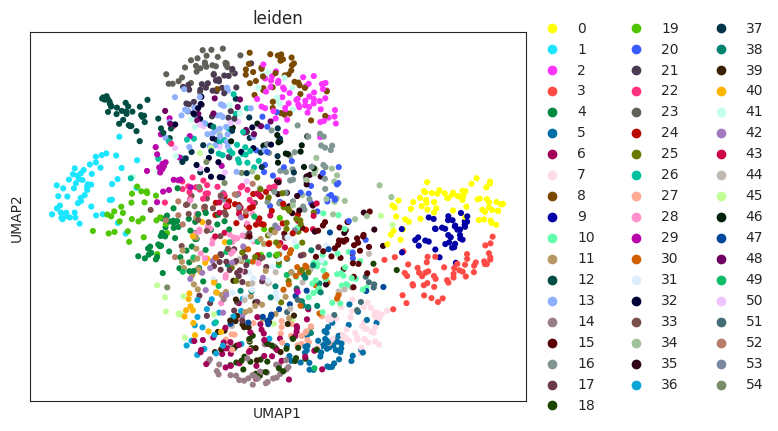

Number of clusters: 55


In [33]:
#Normalize and preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.leiden(adata, resolution=5.0)

sc.tl.umap(adata)  # Compute UMAP
sc.pl.umap(adata, color='leiden')  # Visualize UMAP with clusters

# Save clustering results
num_clusters = adata.obs['leiden'].nunique()
print(f"Number of clusters: {num_clusters}")
adata.write(f'{temporary_outpath}/adata_clustered.h5ad')


In [ ]:

# # Use raw counts for meta-cell construction
# raw_adata = adata.raw.to_adata()
# cluster_labels = adata.obs['leiden']
# unique_clusters = cluster_labels.unique()

# meta_cells = []
# meta_cell_names = []
# for cluster in unique_clusters:
#     cluster_indices = np.where(cluster_labels == cluster)[0]
#     cluster_sum = raw_adata.X[cluster_indices].sum(axis=0)  # Sum raw counts for each cluster
#     meta_cells.append(cluster_sum)
#     num_cells = len(cluster_indices)
#     meta_cell_names.append(f'Cluster {cluster} ({num_cells} cells)')

# # Convert to a new AnnData object
# meta_cells_matrix = np.vstack(meta_cells)
# meta_adata = anndata.AnnData(X=meta_cells_matrix)

# # Add metadata
# meta_adata.obs['cluster'] = meta_cell_names
# meta_adata.obs_names = meta_cell_names  # Set obs_names to include cluster number and cell count
# meta_adata.var = raw_adata.var.copy()  # Copy gene metadata from raw counts

# # Save the meta cells AnnData object
# meta_adata.write_h5ad('/cluster/work/bewi/members/andress/SCICoNE_lab/rna_imp/meta_cells_raw.h5ad')

# print(meta_adata)

AnnData object with n_obs × n_vars = 55 × 17907
    obs: 'cluster'
    var: 'ensembl_gene_id', 'gene_id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'


In [30]:
# Get gene coordinates

adata = anndata.read_h5ad(f'{temporary_outpath}/adata_clustered.h5ad')
df_annotations = gr_annotations.df.set_index('ensembl_gene_id')

df_exp_annotations = df_annotations.loc[df_annotations.index.intersection(adata.var['ensembl_gene_id'])]\
                        .reset_index().rename(columns={'index':'ensembl_gene_id'})

adata.var_names = adata.var['ensembl_gene_id'].values

adata = adata[:,df_exp_annotations['ensembl_gene_id']]

df_exp_annotations_sorted = df_exp_annotations.sort_values(by=['Chromosome', 'End'])

df_exp_annotations_sorted.head()

,ensembl_gene_id,Start,End,Chromosome
191,ENSG00000228327,764723,774280,1
248,ENSG00000237491,778739,810066,1
84,ENSG00000272141,1169357,1170343,1
170,ENSG00000078808,1216931,1232031,1
129,ENSG00000221978,1385711,1399335,1


In [32]:
# Create a clean copy with corrected chromosome names
df_exp_annotations_2 = df_exp_annotations_sorted.copy()
df_exp_annotations_2['Chromosome'] = df_exp_annotations_2['Chromosome'].astype(str).str.strip()

standard_chromosomes = [str(i) for i in range(1, 23)] + ["X", "Y"]
filtered_df = df_exp_annotations_2[df_exp_annotations_2['Chromosome'].isin(standard_chromosomes)]

idx_max = filtered_df.groupby('Chromosome')['End'].idxmax()

# Sort by chromosome order first, then by End
chromosome_stops_df = filtered_df.loc[idx_max, ['Chromosome', 'End', 'ensembl_gene_id']].reset_index(drop=True)

# Create custom chromosome ordering
chromosome_order = {str(i): i for i in range(1, 23)}
chromosome_order.update({'X': 23, 'Y': 24})
chromosome_stops_df['chr_order'] = chromosome_stops_df['Chromosome'].map(chromosome_order)

# Sort by chromosome order
chromosome_stops_df = chromosome_stops_df.sort_values(by='chr_order').drop('chr_order', axis=1).reset_index(drop=True)

# Create a dictionary with chromosomes as keys and last bins as values
chromosome_stops_dict = {row['Chromosome']: int(np.where(adata.var_names == row['ensembl_gene_id'])[0][0])
                         for _, row in chromosome_stops_df.iterrows()}

# Ensure boundaries are included
if 'start' not in chromosome_stops_dict:
    chromosome_stops_dict['start'] = 0

if 'end' not in chromosome_stops_dict:
    chromosome_stops_dict['end'] = adata.shape[1] - 1

print(chromosome_stops_dict)

# Save the dictionary to a JSON file
import json
with open(os.path.join(temporary_outpath, 'chromosome_stops_dict.json'), 'w') as f:
    json.dump(chromosome_stops_dict, f)

print("Chromosome stops dictionary saved to JSON.")

{'1': 48, '2': 271, '3': 468, '4': 620, '5': 699, '6': 753, '7': 911, '8': 993, '9': 1103, '10': 1172, '11': 1220, '12': 1361, '13': 1428, '14': 1482, '15': 1604, '16': 1633, '17': 1728, '18': 1826, '19': 1939, '20': 1973, '21': 2007, '22': 2056, 'X': 2095, 'start': 0, 'end': 2115}
Chromosome stops dictionary saved to JSON.


In [ ]:
# # Compute smoothed average for meta cells
# import numpy as np

# def compute_smoothed_average(meta_adata, window_size=10):
#     """
#     Compute smoothed average for a cluster-by-gene counts matrix.
    
#     Parameters:
#     -----------
#     meta_adata : AnnData
#         AnnData object containing the cluster-by-gene counts matrix.
#     window_size : int
#         Size of the sliding window for smoothing.
    
#     Returns:
#     # --------
#     AnnData
#         Updated AnnData object with smoothed counts.
#     """
#     smoothed_matrix = np.zeros_like(meta_adata.X)
#     half_window = window_size // 2
    
#     for i in range(meta_adata.shape[1]):  # Iterate over genes
#         left = max(0, i - half_window)
#         right = min(i + half_window + 1, meta_adata.shape[1])
#         smoothed_matrix[:, i] = meta_adata.X[:, left:right].mean(axis=1)
    
#     meta_adata.X = smoothed_matrix  # Replace the counts matrix with the smoothed matrix
#     return meta_adata

# # Load meta cells
# meta_adata = anndata.read_h5ad('/cluster/work/bewi/members/andress/SCICoNE_lab/rna_imp/meta_cells.h5ad')

# # Apply smoothing
# meta_adata = compute_smoothed_average(meta_adata, window_size=10)

# # Save the smoothed meta cells
# meta_adata.write_h5ad('/cluster/work/bewi/members/andress/SCICoNE_lab/rna_imp/meta_cells_smoothed.h5ad')

# print("Smoothed average computed and saved.")

In [13]:
chrom_stops = pd.read_csv((os.path.join(temporary_outpath, 'chromosome_stops.csv')), sep=',')
chromosome_stops_list = chrom_stops['Chromosome_stops'].tolist()
# Convert to a flat list
chromosome_stops = [int(i) for i in chromosome_stops_list]

print(chromosome_stops)

[0, 48, 271, 468, 620, 699, 753, 911, 993, 1103, 1172, 1220, 1361, 1428, 1482, 1604, 1633, 1728, 1826, 1939, 1973, 2007, 2056, 2095, 2115]


Sort Data by Genomic Position and Prepare for SCICoNE

In [ ]:
# Create plots comparing matrices before and after sorting

# Create a function to visualize the data matrices
def plot_matrix_heatmap(matrix, title, figsize=(12, 10), gene_subset=None):
    """Plot a heatmap of a data matrix."""
    import matplotlib.pyplot as plt
    
    # Work with a subset of genes if specified
    if gene_subset is not None:
        if isinstance(gene_subset, slice):
            matrix_subset = matrix[:, gene_subset]
        else:
            matrix_subset = matrix[:, :gene_subset]
    else:
        matrix_subset = matrix
    
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix_subset, aspect='auto', cmap='viridis')
    plt.colorbar(im, ax=ax)
    
    # Add chromosome boundaries as vertical lines if available
    if 'chrom_boundaries' in locals() and chrom_boundaries is not None:
        for boundary in chrom_boundaries:
            if gene_subset is None or (isinstance(gene_subset, slice) and boundary in range(gene_subset.start, gene_subset.stop)) or boundary < gene_subset:
                ax.axvline(x=boundary, color='red', linestyle='--', alpha=0.7)
    
    ax.set_title(title)
    ax.set_xlabel('Genes (sorted by genomic position)')
    ax.set_ylabel('Clusters')
    plt.tight_layout()
    return fig, ax

# Plot before and after sorting
# Raw counts
plot_matrix_heatmap(meta_raw.X[:5], "Raw Meta Cells (Original Order)", gene_subset=1000)
plot_matrix_heatmap(meta_raw_sorted.X[:5], "Raw Meta Cells (Sorted by Genomic Position)", gene_subset=1000)

# Mean normalized values
plot_matrix_heatmap(meta_mean.X[:5], "Normalized Mean Meta Cells (Original Order)", gene_subset=1000)
plot_matrix_heatmap(meta_mean_sorted.X[:5], "Normalized Mean Meta Cells (Sorted by Genomic Position)", gene_subset=1000)

plt.show()

# Add Genomic Positions and Sort Data

In [ ]:
# Add 'Chromosome', 'Start', and 'End' to adata_clustered.var
adata_clustered = anndata.read_h5ad(f'{temporary_outpath}/adata_clustered.h5ad')

# Perform a left merge to retain all rows in adata_clustered.var
merged_var = adata_clustered.var.merge(
    df_annotations[['Chromosome', 'Start', 'End']],
    how='left',
    left_on='ensembl_gene_id',
    right_index=True
)

# Ensure the index matches the original var index
merged_var.index = adata_clustered.var.index
adata_clustered.var = merged_var

# Verify the updated var
print(adata_clustered.var[['Chromosome', 'Start', 'End']].head())

                Chromosome      Start        End
ENSG00000228327          1   764723.0   774280.0
ENSG00000237491          1   778739.0   810066.0
ENSG00000272141          1  1169357.0  1170343.0
ENSG00000078808          1  1216931.0  1232031.0
ENSG00000221978          1  1385711.0  1399335.0


In [42]:
# Create a dictionary mapping chromosomes to their respective genes
chrs_dict = {}

# Filter for standard chromosomes
standard_chromosomes = [str(i) for i in range(1, 23)] + ['X', 'Y']
filtered_annotations = gr_annotations.df[gr_annotations.df['Chromosome'].isin(standard_chromosomes)]

# Group genes by chromosome
for chromosome in standard_chromosomes:
    genes_in_chr = filtered_annotations[filtered_annotations['Chromosome'] == chromosome]['ensembl_gene_id'].tolist()
    chrs_dict[chromosome] = genes_in_chr

# Verify the dictionary
print(f"Chromosome dictionary created with {len(chrs_dict)} entries.")
for chr, genes in chrs_dict.items():
    print(f"Chromosome {chr}: {len(genes)} genes")

Chromosome dictionary created with 24 entries.
Chromosome 1: 7095 genes
Chromosome 2: 5685 genes
Chromosome 3: 4161 genes
Chromosome 4: 3580 genes
Chromosome 5: 3946 genes
Chromosome 6: 4230 genes
Chromosome 7: 3957 genes
Chromosome 8: 3268 genes
Chromosome 9: 3190 genes
Chromosome 10: 3269 genes
Chromosome 11: 4170 genes
Chromosome 12: 3860 genes
Chromosome 13: 2000 genes
Chromosome 14: 2797 genes
Chromosome 15: 2819 genes
Chromosome 16: 3188 genes
Chromosome 17: 3780 genes
Chromosome 18: 1654 genes
Chromosome 19: 3550 genes
Chromosome 20: 1970 genes
Chromosome 21: 1134 genes
Chromosome 22: 1748 genes
Chromosome X: 2956 genes
Chromosome Y: 680 genes
